### 다운로드 모델 위치
- C:\Users\<사용자>\.cache\huggingface\hub

In [1]:
from transformers import pipeline

### 텍스트 생성모델

In [2]:
generator = pipeline("text-generation", model="gpt2")
generator("Hello world", max_new_tokens=20)

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

c:\Python310\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\knri0\.cache\huggingface\hub\models--gpt2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Device set to use cpu
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


[{'generated_text': 'Hello world, you\'re going to need someplace to put your cards."\n\n"This is a great'}]

# 문장 --> 단어사전숫자 --> transformer(임베딩해서 학습)

In [3]:
from transformers import AutoTokenizer, AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained("gpt2")
model = AutoModelForCausalLM.from_pretrained("gpt2")

inputs = tokenizer("Hello world", return_tensors="pt")
print( inputs)
outputs = model.generate(**inputs, max_new_tokens=20)
print( outputs)
print(tokenizer.decode(outputs[0]))

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


{'input_ids': tensor([[15496,   995]]), 'attention_mask': tensor([[1, 1]])}
tensor([[15496,   995,    11,   314,  1101,   407,  1654,   644,   284,   910,
            13,   198,   198,     1,    40,  1101,  7926,    11,   475,   314,
          1101,   407]])
Hello world, I'm not sure what to say.

"I'm sorry, but I'm not


### 번역

In [4]:
translator = pipeline('translation_en_to_fr')
result = translator('Hello, how are you?')
print( result )

No model was supplied, defaulted to google-t5/t5-base and revision a9723ea (https://huggingface.co/google-t5/t5-base).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json: 0.00B [00:00, ?B/s]

c:\Python310\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\knri0\.cache\huggingface\hub\models--google-t5--t5-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cpu


[{'translation_text': 'Bonjour, comment êtes-vous?'}]


In [5]:
result[0]['translation_text']

'Bonjour, comment êtes-vous?'

### 멀티모달
## 이미지 to 텍스트

In [6]:
image_to_text = pipeline("image-to-text", 
            model="Salesforce/blip-image-captioning-large")

result = image_to_text( 'image/dog.jpg')
print( result )

c:\Python310\lib\site-packages\transformers\models\auto\modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/527 [00:00<?, ?B/s]

c:\Python310\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\knri0\.cache\huggingface\hub\models--Salesforce--blip-image-captioning-large. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/445 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Device set to use cpu


[{'generated_text': 'there is a white dog sitting in the grass with a leash'}]


In [7]:
print( result[0]['generated_text'] )

there is a white dog sitting in the grass with a leash


음성 텍스트 변환 모델:whisper

음성 텍스트 변환 모델: whisper
https://ffmpeg.org/download.html
- mp3 :ffmpeg 코덱 필요 압축해제후 ffmpeg/bin path 환경변수 등록

## 슈퍼개인

In [8]:
from transformers import pipeline

pipe = pipeline("automatic-speech-recognition",
                model="openai/whisper-small")
result = pipe( 'audio/베트남여행.mp3', return_timestamps=True)
result

config.json: 0.00B [00:00, ?B/s]

c:\Python310\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\knri0\.cache\huggingface\hub\models--openai--whisper-small. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors:   0%|          | 0.00/967M [00:00<?, ?B/s]

generation_config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

preprocessor_config.json: 0.00B [00:00, ?B/s]

Device set to use cpu
Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
Transcription using a multilingual Whisper will default to language detection followed by transcription instead of translation to English. This might be a breaking change for your use case. If you want to instead always translate your audio to English, make sure to pass `language='en'`. See https://github.com/huggingface/transformers/pull/28687 for more details.


{'text': ' 베트남 여행 준빔을 30초로 정리하세요. 첫 번째, 100달러 집회입니다. 달러 금액별로 다르게 환전해주는데 큰 금액의 달러를 더 잘 쳐줍니다. 두 번째, 트래블 원래카드. 트래블 원래카드를 이용하면 환전 수수료를 100% 우대해주고 베트남 비피뱅크 ATM을 이용하면 인출 수수료도 우려라는 사실 바로 환전할 수 있어서 편합니다. 세 번째, 동지갑. 저는 만들기 귀찮아서 샀는데요. 워낙 집회 종류가 많다 보니 이렇게 구분되어 있는 지갑을 가져가시는 걸 추천드립니다. 네 번째, 멀티텔. 보조 배터리, 미니 선풍기, 휴대폰 등등 충전할 전자 기기가 너무 많죠? 웰티탭 챙겨가시면 편합니다 참고로 베트남은 대부분 220v 쓰니까 변화기에는 필요 없습니다 마지막으로 과도랑 포크 망고 사드실 거면 챙겨가세요 기내는 못 들고 타는 거 아시죠? 꼭 위탁수화물에 붙이세요 나머지는 댓글에 상세히 남겨두겠습니다 구독하고 여행 꿀팁, 맛집 정보 받아보세요',
 'chunks': [{'timestamp': (0.0, 2.44), 'text': ' 베트남 여행 준빔을 30초로 정리하세요.'},
  {'timestamp': (2.44, 4.34), 'text': ' 첫 번째, 100달러 집회입니다.'},
  {'timestamp': (4.34, 6.54), 'text': ' 달러 금액별로 다르게 환전해주는데'},
  {'timestamp': (6.54, 8.54), 'text': ' 큰 금액의 달러를 더 잘 쳐줍니다.'},
  {'timestamp': (8.54, 10.44), 'text': ' 두 번째, 트래블 원래카드.'},
  {'timestamp': (10.44, 12.14), 'text': ' 트래블 원래카드를 이용하면'},
  {'timestamp': (12.14, 14.2), 'text': ' 환전 수수료를 100% 우대해주고'},
  {'timestamp': (14.2, 16.3), 'text': ' 베트남 비피뱅크 ATM을 이용하면'},
  {'time

In [9]:
result['text']

' 베트남 여행 준빔을 30초로 정리하세요. 첫 번째, 100달러 집회입니다. 달러 금액별로 다르게 환전해주는데 큰 금액의 달러를 더 잘 쳐줍니다. 두 번째, 트래블 원래카드. 트래블 원래카드를 이용하면 환전 수수료를 100% 우대해주고 베트남 비피뱅크 ATM을 이용하면 인출 수수료도 우려라는 사실 바로 환전할 수 있어서 편합니다. 세 번째, 동지갑. 저는 만들기 귀찮아서 샀는데요. 워낙 집회 종류가 많다 보니 이렇게 구분되어 있는 지갑을 가져가시는 걸 추천드립니다. 네 번째, 멀티텔. 보조 배터리, 미니 선풍기, 휴대폰 등등 충전할 전자 기기가 너무 많죠? 웰티탭 챙겨가시면 편합니다 참고로 베트남은 대부분 220v 쓰니까 변화기에는 필요 없습니다 마지막으로 과도랑 포크 망고 사드실 거면 챙겨가세요 기내는 못 들고 타는 거 아시죠? 꼭 위탁수화물에 붙이세요 나머지는 댓글에 상세히 남겨두겠습니다 구독하고 여행 꿀팁, 맛집 정보 받아보세요'

### 이미지 분류

In [10]:
image_classification = pipeline("image-classification", 
                model="google/vit-base-patch16-224")
result = image_classification('image/dog.jpg')
result

config.json: 0.00B [00:00, ?B/s]

c:\Python310\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\knri0\.cache\huggingface\hub\models--google--vit-base-patch16-224. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.
Device set to use cpu


[{'label': 'Pomeranian', 'score': 0.5806371569633484},
 {'label': 'Samoyed, Samoyede', 'score': 0.11738205701112747},
 {'label': 'Eskimo dog, husky', 'score': 0.05820711702108383},
 {'label': 'chow, chow chow', 'score': 0.03379051387310028},
 {'label': 'papillon', 'score': 0.01847870834171772}]

In [11]:
image_classification('image/cup.jpg')

[{'label': 'coffee mug', 'score': 0.7028843760490417},
 {'label': 'cup', 'score': 0.2455562800168991},
 {'label': 'pitcher, ewer', 'score': 0.01506818924099207},
 {'label': 'water jug', 'score': 0.015000773593783379},
 {'label': 'coffeepot', 'score': 0.006545419804751873}]

얼굴 표정

In [12]:
# Use a pipeline as a high-level helper
from transformers import pipeline

pipe = pipeline("image-classification", 
            model="RickyIG/emotion_face_image_classification_v3")
pipe("image/d.jpg")

config.json:   0%|          | 0.00/957 [00:00<?, ?B/s]

c:\Python310\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\knri0\.cache\huggingface\hub\models--RickyIG--emotion_face_image_classification_v3. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


pytorch_model.bin:   0%|          | 0.00/343M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/325 [00:00<?, ?B/s]

Device set to use cpu


[{'label': 'disgust', 'score': 0.6563716530799866},
 {'label': 'anger', 'score': 0.13610640168190002},
 {'label': 'fear', 'score': 0.0753745585680008},
 {'label': 'sad', 'score': 0.05914681404829025},
 {'label': 'contempt', 'score': 0.023369161412119865}]

In [13]:
import os
os.environ["USE_FLASH_ATTENTION"] = "0"


### 이미지 생성

In [14]:
%pip install diffusers

model.safetensors:   0%|          | 0.00/343M [00:00<?, ?B/s]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
%pip install accelerate

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


c:\Python310\lib\site-packages\torch\amp\autocast_mode.py:270: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

c:\Python310\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\knri0\.cache\huggingface\hub\models--CompVis--stable-diffusion-v1-4. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

scheduler_config-checkpoint.json:   0%|          | 0.00/209 [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

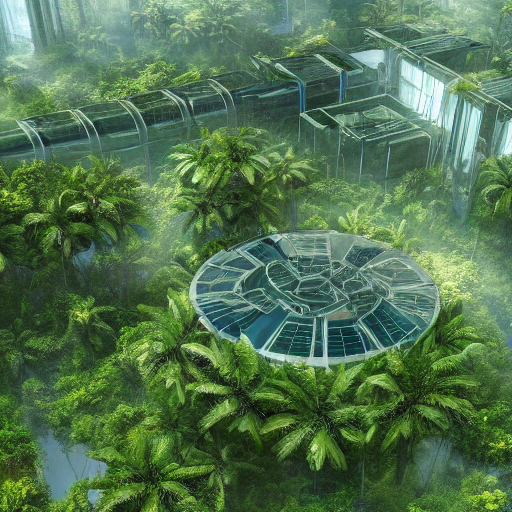

In [16]:
from diffusers import DiffusionPipeline

pipe = DiffusionPipeline.from_pretrained("CompVis/stable-diffusion-v1-4")

prompt = "A high tech solarpunk utopia in the Amazon rainforest"
image = pipe(prompt).images[0]
image

In [17]:
prompt = "cute cat"
# num_inference_step: 값이 클수록 이미지 품질이 높음 
# guidance_scale: 이미지 품질과 프롬프트 일치도를 조정: 7.5
images = pipe(prompt, num_inference_step=50,guidance_scale=7.5 )
images

  0%|          | 0/50 [00:00<?, ?it/s]

StableDiffusionPipelineOutput(images=[<PIL.Image.Image image mode=RGB size=512x512 at 0x22CBB7FD1B0>], nsfw_content_detected=[False])

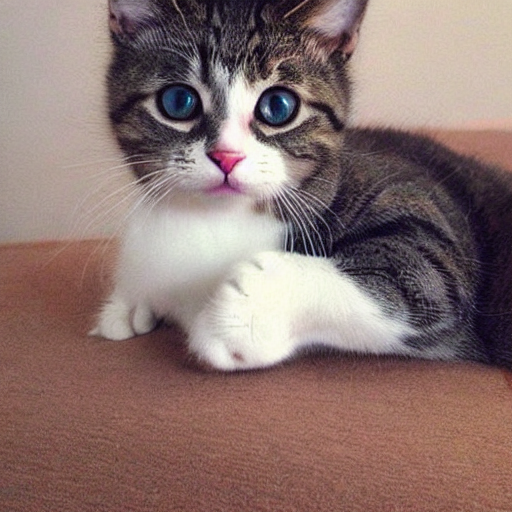

In [18]:
images.images[0]

### 객체 탐지

In [19]:
%pip install timm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
from transformers import pipeline
import warnings
warnings.simplefilter('ignore')

detector = pipeline("object-detection", 
                model="facebook/detr-resnet-50")
result = detector('image/catdog.jpg')
result

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/167M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Some weights of the model checkpoint at facebook/detr-resnet-50 were not used when initializing DetrForObjectDetection: ['model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing DetrForObjectDetection from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DetrForObjectDetection from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


preprocessor_config.json:   0%|          | 0.00/290 [00:00<?, ?B/s]

Device set to use cpu


[{'score': 0.9404653906822205,
  'label': 'dog',
  'box': {'xmin': 18, 'ymin': 25, 'xmax': 182, 'ymax': 177}},
 {'score': 0.9624136090278625,
  'label': 'cat',
  'box': {'xmin': 124, 'ymin': 48, 'xmax': 253, 'ymax': 172}}]

In [21]:
for r in result:
    print( f"라벨:{r['label']}, 확률:{ r['score'] }, 위치:{r['box']} ")

라벨:dog, 확률:0.9404653906822205, 위치:{'xmin': 18, 'ymin': 25, 'xmax': 182, 'ymax': 177} 
라벨:cat, 확률:0.9624136090278625, 위치:{'xmin': 124, 'ymin': 48, 'xmax': 253, 'ymax': 172} 


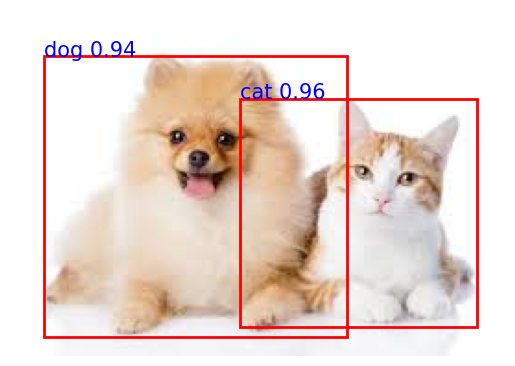

In [22]:
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

image = Image.open('image/catdog.jpg')

fig, ax = plt.subplots(1)
ax.imshow( image)
for r in result:
    box = r['box']
    rect = patches.Rectangle(
        (box['xmin'], box['ymin']),
        box['xmax'] - box['xmin'],
        box['ymax'] - box['ymin'],
        linewidth=2,
        edgecolor='r',
        facecolor='none'
    )
    ax.add_patch(rect)
    ax.text( box['xmin'], box['ymin'], f"{r['label']} {r['score']:.2f}",
            color='blue', fontsize=15  )
plt.axis('off')
plt.show()

In [23]:
%pip install opencv-python

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
%pip install ultralytics


     ---------------------------------------- 1.2/1.2 MB 12.5 MB/s eta 0:00:00
     ------------------------------------- 805.7/805.7 kB 24.9 MB/s eta 0:00:00
     --------------------------------------- 44.9/44.9 MB 24.2 MB/s eta 0:00:00



[notice] A new release of pip available: 22.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')
rst = model.predict( 'image/catdog.jpg')[0]
rst

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\knri0\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

image 1/1 c:\\LLMTest\\image\catdog.jpg: 448x640 2 cats, 1 dog, 73.8ms
Speed: 4.2ms preprocess, 73.8ms inference, 4.3ms postprocess per image at shape (1, 3, 448, 640)


ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant',

In [26]:
rst.names

{0: 'person',
 1: 'bicycle',
 2: 'car',
 3: 'motorcycle',
 4: 'airplane',
 5: 'bus',
 6: 'train',
 7: 'truck',
 8: 'boat',
 9: 'traffic light',
 10: 'fire hydrant',
 11: 'stop sign',
 12: 'parking meter',
 13: 'bench',
 14: 'bird',
 15: 'cat',
 16: 'dog',
 17: 'horse',
 18: 'sheep',
 19: 'cow',
 20: 'elephant',
 21: 'bear',
 22: 'zebra',
 23: 'giraffe',
 24: 'backpack',
 25: 'umbrella',
 26: 'handbag',
 27: 'tie',
 28: 'suitcase',
 29: 'frisbee',
 30: 'skis',
 31: 'snowboard',
 32: 'sports ball',
 33: 'kite',
 34: 'baseball bat',
 35: 'baseball glove',
 36: 'skateboard',
 37: 'surfboard',
 38: 'tennis racket',
 39: 'bottle',
 40: 'wine glass',
 41: 'cup',
 42: 'fork',
 43: 'knife',
 44: 'spoon',
 45: 'bowl',
 46: 'banana',
 47: 'apple',
 48: 'sandwich',
 49: 'orange',
 50: 'broccoli',
 51: 'carrot',
 52: 'hot dog',
 53: 'pizza',
 54: 'donut',
 55: 'cake',
 56: 'chair',
 57: 'couch',
 58: 'potted plant',
 59: 'bed',
 60: 'dining table',
 61: 'toilet',
 62: 'tv',
 63: 'laptop',
 64: 'mou

In [27]:
for box in rst.boxes:
    print( box.xyxy)

tensor([[156.4207,  48.7694, 252.0200, 168.9517]])
tensor([[ 60.0653,  23.6553, 184.1008, 175.9214]])
tensor([[ 58.2895,  23.6239, 184.1063, 175.4826]])


In [ ]:
# image = Image.open( 'image/catdog.jpg')

from ultralytics import YOLO
import cv2
model = YOLO('yolov8n.pt')
rst = model.predict( 'image/catdog.jpg')[0]

image = cv2.imread('image/catdog.jpg' )
for box in rst.boxes:
    print( box.xyxy )
    x1,y1, x2, y2 = map(int,  box.xyxy[0] )
    conf = box.conf[0]
    cls = int( box.cls[0] )
    label = model.names[cls]

    if conf > 0.3:
        cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText( image, f'{label}', (x1,y1), cv2.FONT_HERSHEY_SIMPLEX, 0.6,
                    (0,255,0), 2)

cv2.imshow( "yolo", image)
cv2.waitKey(0)

cv2.destroyWindow('yolo')


image 1/1 c:\\LLMTest\\image\catdog.jpg: 448x640 2 cats, 1 dog, 65.9ms
Speed: 2.8ms preprocess, 65.9ms inference, 0.7ms postprocess per image at shape (1, 3, 448, 640)
tensor([[156.4207,  48.7694, 252.0200, 168.9517]])
tensor([[ 60.0653,  23.6553, 184.1008, 175.9214]])
tensor([[ 58.2895,  23.6239, 184.1063, 175.4826]])
